# **[August 2026] Updated code for the research paper purpose**

In [1]:
%%writefile plot_complexity_figure.py
"""
plot_complexity_figure.py

Figure 1: the merged two-panel complexity comparison.
  Panel A: integer factorization -- classical GNFS vs. quantum Shor
  Panel B: LWE -- classical brute-force vs. quantum Grover

REPLACES the two separate complexity plots from the original notebook.
Changes relative to that code, and why:

1. GNFS CONSTANT FIXED. The old code used c = 64/9 (~7.11) inside
   exp(c * (ln N)^(1/3) * (ln ln N)^(2/3)). The standard GNFS complexity
   L_N[1/3, c] uses c = (64/9)^(1/3) (~1.923) -- the cube root belongs on
   the constant, not just the ln N term. The old value inflated the
   exponent ~3.7x. The qualitative conclusion (sub-exponential vs.
   polynomial) is unchanged, but a reviewer who knows GNFS would catch
   the constant, so it is now correct. If the Methods text states the
   complexity form, state it as exp(((64/9)^(1/3)) (ln N)^(1/3) (ln ln N)^(2/3)).

2. time.sleep() "simulation" REMOVED. The old gnfs_simulation() slept
   for min(complexity/1e10, 2) seconds and timed the sleep -- the timing
   measured nothing but the sleep itself. Complexity values are analytic;
   they are now computed directly. (Describe this in Methods as
   "complexity models were evaluated", not as timed simulations.)

3. RED+GREEN ELIMINATED. The old plots drew classical in red and quantum
   in green -- the exact color pairing JEI's figure guide warns against
   (most common form of colorblindness). Both panels now use
   blue = classical attack, orange = quantum attack (validated
   colorblind-safe pair, CVD deltaE 26.7), with distinct markers and line
   styles as secondary encoding, consistent across panels.

4. NO ON-GRAPH TITLES (JEI rule) -- bare bold panel letters A)/B); the
   descriptive title belongs in the manuscript caption. Filename keeps a
   description while drafts are in flux; rename to plain "Figure 1.png"
   before Editorial Manager upload.

Deterministic (pure math, no benchmarking) -- runs anywhere with
matplotlib; no liboqs or Colab needed.
"""

import math
import numpy as np
import matplotlib.pyplot as plt

CLASSICAL_COLOR = "#2166AC"   # blue  = classical attack (both panels)
QUANTUM_COLOR = "#E08214"     # orange = quantum attack  (both panels)

GNFS_C = (64 / 9) ** (1 / 3)  # ~1.923 -- see note 1 above

def gnfs_complexity(n_bits: int) -> float:
    """Classical GNFS: L_N[1/3, (64/9)^(1/3)] operations (scaled estimate)."""
    ln_n = n_bits * math.log(2)          # ln(N) for an n-bit modulus
    lln_n = math.log(ln_n)
    return math.exp(GNFS_C * (ln_n ** (1 / 3)) * (lln_n ** (2 / 3)))

def shor_complexity(n_bits: int) -> float:
    """Quantum Shor: O((log N)^3) operations (scaled estimate)."""
    return float(n_bits) ** 3

def lwe_classical_complexity(dimension: int) -> float:
    """Classical attack on LWE: O(2^n) (scaled estimate, c = 1)."""
    return 2.0 ** dimension

def lwe_grover_complexity(dimension: int) -> float:
    """Quantum (Grover-assisted) attack on LWE: O(2^(n/2))."""
    return 2.0 ** (dimension / 2)

def plot_complexity_figure(save_path: str = "figures/Figure 1.png", show=True):
    modulus_bits = [256, 512, 1024, 2048, 4096, 8192]
    dimensions = [50, 100, 150, 200, 256, 300, 512]

    gnfs = [gnfs_complexity(b) for b in modulus_bits]
    shor = [shor_complexity(b) for b in modulus_bits]
    lwe_c = [lwe_classical_complexity(d) for d in dimensions]
    lwe_q = [lwe_grover_complexity(d) for d in dimensions]

    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(12, 5.2))

    def label_point(ax, x, y, dy=10, dx=0, ha="center"):
        """Selective value label: order of magnitude only (these are scaled
        analytic estimates -- exact digits would imply false precision).
        Endpoint labels use ha="right" + negative dx so they sit INSIDE the
        axes instead of spilling over the top/right border."""
        exponent = int(math.floor(math.log10(y)))
        ax.annotate(f"$\\sim10^{{{exponent}}}$", (x, y), xytext=(dx, dy),
                    textcoords="offset points", ha=ha, fontsize=9)

    # --- Panel A: integer factorization (RSA's foundation) ---
    ax_a.plot(modulus_bits, gnfs, "o-", color=CLASSICAL_COLOR, linewidth=2,
              markersize=7, label="Classical (GNFS)")
    ax_a.plot(modulus_bits, shor, "s--", color=QUANTUM_COLOR, linewidth=2,
              markersize=7, label="Quantum (Shor)")
    ax_a.set_yscale("log")
    ax_a.set_xscale("log", base=2)
    ax_a.set_xticks(modulus_bits)
    ax_a.set_xticklabels([str(b) for b in modulus_bits])
    ax_a.set_xlabel("RSA modulus size (bits)")
    ax_a.set_ylabel("Estimated operations (log scale)")
    ax_a.set_title("A)", loc="left", fontweight="bold")
    ax_a.legend(loc="upper left")
    ax_a.grid(True, alpha=0.3)
    # Selective labels: the deployed-standard key size (2048) and the endpoint --
    # the same values quoted in the Results text.
    ax_a.margins(y=0.15)
    label_point(ax_a, 2048, gnfs_complexity(2048), dy=10)
    label_point(ax_a, 2048, shor_complexity(2048), dy=-20)
    label_point(ax_a, 8192, gnfs_complexity(8192), dx=-10, dy=-4, ha="right")
    label_point(ax_a, 8192, shor_complexity(8192), dx=-10, dy=-14, ha="right")

    # --- Panel B: LWE (Kyber's and FrodoKEM's foundation) ---
    ax_b.plot(dimensions, lwe_c, "o-", color=CLASSICAL_COLOR, linewidth=2,
              markersize=7, label="Classical (brute force)")
    ax_b.plot(dimensions, lwe_q, "s--", color=QUANTUM_COLOR, linewidth=2,
              markersize=7, label="Quantum (Grover)")
    ax_b.set_yscale("log")
    ax_b.set_xlabel("Lattice dimension n")
    ax_b.set_ylabel("Estimated operations (log scale)")
    ax_b.set_title("B)", loc="left", fontweight="bold")
    ax_b.legend(loc="upper left")
    ax_b.grid(True, alpha=0.3)
    # Selective labels at n=256 (a cryptographically relevant dimension) and
    # the endpoint -- matching the values quoted in the Results text.
    ax_b.margins(y=0.15)
    label_point(ax_b, 256, lwe_classical_complexity(256), dy=10, dx=-6)
    label_point(ax_b, 256, lwe_grover_complexity(256), dy=-16, dx=-6)
    label_point(ax_b, 512, lwe_classical_complexity(512), dx=-10, dy=-4, ha="right")
    label_point(ax_b, 512, lwe_grover_complexity(512), dx=-14, dy=-20, ha="right")

    # NOTE: no fig.suptitle() -- JEI prohibits on-graph titles; the
    # descriptive title belongs in the manuscript's figure caption.
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)      # release instead of leaking
    print(f"Saved to {save_path}")

    # Numbers worth quoting in Results -- floored orders of magnitude, so the
    # quoted text matches the on-graph labels exactly:
    oom = lambda v: int(math.floor(math.log10(v)))
    print(f"\nAt 2048-bit RSA: GNFS ~10^{oom(gnfs_complexity(2048))} ops "
          f"vs Shor ~10^{oom(shor_complexity(2048))} ops")
    print(f"At n=256 LWE:  classical ~10^{oom(lwe_classical_complexity(256))} ops "
          f"vs Grover ~10^{oom(lwe_grover_complexity(256))} ops (still astronomically hard)")
    print(f"Note for text: Grover at n=512 (~10^{oom(lwe_grover_complexity(512))}) equals "
          f"classical at n=256 (~10^{oom(lwe_classical_complexity(256))}) -- "
          f"the 'double the dimension' defense, visible directly on the graph.")


if __name__ == "__main__":
    # Force a non-interactive backend when run as a script, so an interactive
    # backend can never block waiting for a window to be closed. Fires only
    # under `python plot_complexity_figure.py`; importing the function into a
    # notebook leaves the inline backend untouched.
    import matplotlib
    matplotlib.use("Agg")

    file_path = sys.argv[1] if len(sys.argv) > 1 else "figures/Figure 1 - Quantum Complexity Comparison.png"
    plot_complexity_figure(file_path, show=False)

Writing plot_complexity_figure.py


# Caption draft, reword for manuscript
Figure 1. Quantum computing collapses the cost of breaking RSA but leaves lattice-based cryptography intact. Estimated attack cost (operations, log scale) from analytic complexity models. (A) Integer factorization, the problem underlying RSA, for modulus sizes of 256–8192 bits: the classical General Number Field Sieve, modeled as exp((64/9)^(1/3) (ln N)^(1/3) (ln ln N)^(2/3)), versus Shor's quantum algorithm, modeled as O((log N)^3). (B) The Learning With Errors problem underlying Kyber and FrodoKEM, for lattice dimensions 50–512: classical brute-force search, modeled as O(2^n), versus Grover-assisted quantum search, modeled as O(2^(n/2)). Values are scaled analytic estimates rather than measured runtimes; selected points are labeled with their order of magnitude.

In [2]:
%%writefile rsa_implementation.py
"""
rsa_implementation.py

Core RSA key generation, serialization, encryption, and decryption helpers
used by benchmark_rsa.py and main.py.

NOTE ON FILENAME: this module was previously named RSA_Implementation.py.
It has been renamed to lowercase (rsa_implementation.py) because Python
module names are conventionally lowercase, and because the old mixed-case
filename combined with a lowercase `from rsa_implementation import ...`
in main_rsa-test caused an ImportError on case-sensitive filesystems
(Linux, macOS default in some configs, GitHub Actions, Google Colab),
even though it worked by accident on case-insensitive Windows filesystems.
If you keep the old filename, update every import to match it exactly.
"""

from cryptography.hazmat.primitives.asymmetric import rsa
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.backends import default_backend


def generate_rsa_key_pair(key_size: int):
    """
    Generate an RSA key pair.

    Args:
        key_size: RSA key size in bits (e.g. 1024, 2048, 3072, 4096, 8192).

    Returns:
        (private_key, public_key) tuple.
    """
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=key_size,
        backend=default_backend(),
    )
    public_key = private_key.public_key()
    return private_key, public_key


def serialize_key(key, is_private: bool = True) -> bytes:
    """Serialize an RSA key to PEM format."""
    if is_private:
        return key.private_bytes(
            encoding=serialization.Encoding.PEM,
            format=serialization.PrivateFormat.TraditionalOpenSSL,
            encryption_algorithm=serialization.NoEncryption(),
        )
    return key.public_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PublicFormat.SubjectPublicKeyInfo,
    )


def max_oaep_plaintext_bytes(key_size_bits: int, hash_len_bytes: int = 32) -> int:
    """
    Return the maximum plaintext length (bytes) that RSA-OAEP can encrypt
    for a given key size and hash function.

    Formula (RFC 8017): max = k - 2*hLen - 2, where k = key size in bytes.
    Default hash_len_bytes=32 matches SHA-256, used in encrypt_message below.
    """
    k = key_size_bits // 8
    return k - 2 * hash_len_bytes - 2


def encrypt_message(message: bytes, public_key) -> bytes:
    """Encrypt `message` (bytes) with RSA-OAEP (SHA-256 / MGF1-SHA256)."""
    return public_key.encrypt(
        message,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None,
        ),
    )


def decrypt_message(encrypted_message: bytes, private_key) -> bytes:
    """Decrypt `encrypted_message` (bytes) with RSA-OAEP (SHA-256 / MGF1-SHA256)."""
    return private_key.decrypt(
        encrypted_message,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None,
        ),
    )

Writing rsa_implementation.py


In [3]:
%%writefile benchmark_rsa.py
"""
benchmark_rsa.py

Benchmarks RSA key generation, encryption, and decryption across key sizes
and message sizes, and produces line-chart, heatmap, and multi-panel
scaling visualizations.

Fixes applied relative to the original benchmark-rsa.py (see git history /
project conversation log for full detail on each):
  1. Added the missing import of rsa_implementation functions (the old
     script called generate_rsa_key_pair/encrypt_message/etc. without
     importing them -> guaranteed NameError).
  2. Removed the double key-generation per trial (was: once for timing,
     once inside a memory-measurement call).
  3. Replaced the `lipsum` word-based message generator with
     os.urandom-based byte generation, sized exactly to message_size.
  4. Skip (key_size, message_size) combinations that exceed the RSA-OAEP
     plaintext ceiling *before* attempting encryption, with a clear log
     message, instead of silently getting None back from a caught
     exception.
  5. Fixed a broken plot_heatmaps() call whose arguments didn't match its
     own signature (guaranteed crash).
  6. Key generation is shared across message_sizes within each sample
     (one key per (sample, key_size), reused for every message_size),
     since keygen cost doesn't depend on message_size at all -- cuts
     RSA-8192's keygen count 7x for a 7-message_size sweep.
  7. Incremental checkpointing + resume support, so a Colab disconnect
     only costs the in-progress key size, and per-key-size sample count
     overrides (key_size_samples) for cases where measurement noise
     differs sharply by key size.
  8. Untimed warm-up call before the timed message_size loop, after
     discovering that the FIRST encrypt+decrypt call against any freshly
     generated key pays a one-time ~2x cost (likely OpenSSL lazily
     setting up Montgomery/blinding context on first use) -- this had
     been contaminating message_size=16 specifically in every sample.
  9. Key generation MEMORY measurement was removed entirely (not just
     unused) after verification showed both tracemalloc (sees ~24 bytes
     regardless of key size, since the real work happens in Rust/C via
     OpenSSL, outside Python's allocator) and process-level RSS-delta
     (confounded by allocator reuse, non-monotonic) were fundamentally
     broken, not just noisy. Memory usage was dropped from the paper
     entirely rather than publish either broken measurement -- see
     _benchmark_keygen()'s docstring for detail if this needs revisiting.
"""

import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rsa_implementation import (
    generate_rsa_key_pair,
    serialize_key,
    encrypt_message,
    decrypt_message,
    max_oaep_plaintext_bytes,
)

def _benchmark_keygen(key_size: int):
    """
    Generate one RSA key pair and time it. Split out from encryption/
    decryption benchmarking so the (expensive) keygen step can be run
    ONCE per (sample, key_size) and the resulting key reused across every
    message_size tested against it -- see collect_benchmark_data()
    docstring for why this matters.

    NOTE: this function previously also measured peak memory via
    tracemalloc. That was removed after verification showed it was
    fundamentally broken, not just noisy: tracemalloc only tracks
    Python-level heap allocations, but the `cryptography` library's
    actual RSA key generation (prime search, Miller-Rabin testing, CRT
    parameter computation) happens in Rust/C code calling into OpenSSL,
    entirely outside Python's allocator -- it reported ~24 bytes
    regardless of key size (1024 through 8192 bits). A process-level
    RSS-delta measurement was also tried and rejected (confounded by
    memory allocator reuse, producing a non-monotonic result where
    1024-bit appeared to use MORE memory than 2048/3072/4096-bit). Memory
    usage was subsequently dropped from the paper entirely rather than
    publish either broken measurement. If you need this later, it would
    require running each key size in an isolated subprocess and sampling
    RSS during execution, not before/after.
    """
    start_time = time.perf_counter()
    private_key, public_key = generate_rsa_key_pair(key_size)
    key_gen_time = time.perf_counter() - start_time

    start_time = time.perf_counter()
    serialize_key(private_key)
    serialization_time = time.perf_counter() - start_time
    serialize_key(public_key, is_private=False)

    return private_key, public_key, key_gen_time, serialization_time


def _benchmark_encrypt_decrypt(key_size: int, message_size: int, private_key, public_key):
    """
    Time encryption/decryption of a random message_size-byte message
    against an ALREADY-GENERATED key pair. Does not touch key generation.
    """
    result = {
        "encryption_time": None,
        "decryption_time": None,
        "ciphertext_size": None,
        "skipped_reason": None,
    }

    max_bytes = max_oaep_plaintext_bytes(key_size)
    if message_size > max_bytes:
        result["skipped_reason"] = (
            f"message_size={message_size}B exceeds RSA-OAEP/SHA-256 max "
            f"plaintext ({max_bytes}B) for a {key_size}-bit key"
        )
        return result

    message = os.urandom(message_size)
    try:
        start_time = time.perf_counter()
        encrypted_message = encrypt_message(message, public_key)
        result["encryption_time"] = time.perf_counter() - start_time
        result["ciphertext_size"] = len(encrypted_message)

        start_time = time.perf_counter()
        decrypted_message = decrypt_message(encrypted_message, private_key)
        result["decryption_time"] = time.perf_counter() - start_time

        assert decrypted_message == message, "Decryption did not round-trip!"
    except Exception as e:  # pragma: no cover - defensive logging path
        result["skipped_reason"] = f"unexpected error: {e}"

    return result


def benchmark_rsa(key_size: int, message_size: int):
    """
    Benchmark RSA key generation + encryption + decryption for a single
    (key_size, message_size) pair, generating a fresh key each call.

    Kept for standalone/ad-hoc use (e.g. testing one combination). For
    sweeping multiple message_sizes against the same key_size, use
    collect_benchmark_data() instead -- it reuses one key across all
    message_sizes per sample rather than paying keygen cost repeatedly.
    """
    private_key, public_key, key_gen_time, serialization_time = \
        _benchmark_keygen(key_size)
    result = _benchmark_encrypt_decrypt(key_size, message_size, private_key, public_key)
    result.update({
        "key_size": key_size,
        "message_size": message_size,
        "key_gen_time": key_gen_time,
        "serialization_time": serialization_time,
    })
    return result


def collect_benchmark_data(key_sizes, message_sizes, num_samples=10, key_size_samples=None,
                            checkpoint_path="rsa_benchmark_checkpoint.csv", resume=True):
    """
    Run the RSA benchmark across all (key_size, message_size) combinations
    and return a tidy DataFrame.

    KEY GENERATION IS SHARED ACROSS message_sizes WITHIN EACH SAMPLE: for
    each (sample_idx, key_size), ONE key pair is generated and reused for
    every message_size tested against it in that sample, since keygen cost
    does not depend on message_size at all.

    key_size_samples: optional dict overriding num_samples for specific
    key sizes, e.g. {1024: 500, 2048: 100}. Use this when relative noise in
    the timing measurements differs sharply by key size -- which it does
    here: RSA-1024's encryption time (a very fast, small-fixed-exponent
    operation) showed std/mean = 1.79 at n=10 (std larger than the mean,
    driven by a single scheduling-noise outlier), while 2048/3072/4096/
    8192-bit all showed a much tighter ~0.19-0.22. Recommended based on
    that measured noise: key_size_samples={1024: 500, 2048: 100}, leaving
    3072/4096/8192 at whatever num_samples you'd already planned (they're
    already precise enough at n=10; no need to pay extra keygen cost on
    the expensive 8192-bit case for a precision gain it doesn't need).
    Key sizes not present in this dict fall back to num_samples.

    INCREMENTAL CHECKPOINTING: after each (sample_idx, key_size) finishes
    (its keygen plus every message_size tested in that sample), results
    are immediately appended to `checkpoint_path`. This matters on Colab,
    where sessions can idle-disconnect (~90 min) or occasionally get
    preempted for resource reasons even mid-run.

    resume: if True (default) and checkpoint_path already exists from an
    earlier (possibly interrupted) call, already-completed
    (sample_idx, key_size) combinations are loaded from it and SKIPPED --
    the run continues from wherever it left off rather than starting
    over. Set resume=False to ignore/overwrite an existing checkpoint and
    start completely fresh. NOTE: if you change key_size_samples between
    runs (e.g. bumping 1024-bit from 10 to 500 after an initial run),
    resume will correctly add ONLY the new samples needed to reach the
    new target for each key size, not redo everything.
    """
    key_size_samples = key_size_samples or {}

    completed_combos = set()
    existing_rows = []
    if resume and os.path.exists(checkpoint_path):
        existing_df = pd.read_csv(checkpoint_path)
        existing_rows = existing_df.to_dict("records")
        completed_combos = set(zip(existing_df["sample_idx"], existing_df["key_size"]))
        print(f"[resume] Found checkpoint at {checkpoint_path}: {len(existing_rows)} rows "
              f"across {len(completed_combos)} completed (sample, key_size) combinations. "
              f"Skipping those and continuing.")
    elif not resume and os.path.exists(checkpoint_path):
        os.remove(checkpoint_path)
        print(f"[resume=False] Removed existing checkpoint at {checkpoint_path}; starting fresh.")

    results = list(existing_rows)
    total_combos = sum(key_size_samples.get(k, num_samples) for k in key_sizes)
    done_combos = len(completed_combos)

    for key_size in key_sizes:
        samples_for_this_key = key_size_samples.get(key_size, num_samples)
        for sample_idx in range(samples_for_this_key):
            if (sample_idx, key_size) in completed_combos:
                continue  # already benchmarked in a previous (interrupted) call

            private_key, public_key, key_gen_time, serialization_time = \
                _benchmark_keygen(key_size)

            # Untimed warm-up call, discarded from results. Confirmed via a
            # controlled test (holding message_size constant and varying
            # only call position after a fresh key) that the FIRST
            # encrypt+decrypt call against any freshly generated key pays
            # a one-time cost roughly 2x a steady-state call -- likely
            # OpenSSL lazily setting up Montgomery/blinding context on
            # first use, then caching it. Since message_sizes is iterated
            # in the same fixed order every time, this warm-up cost always
            # landed on message_size=16 specifically in every sample,
            # making it LOOK like a message-size effect when it was
            # actually a loop-position artifact. 16 bytes is used here
            # since it fits under every tested key size's OAEP ceiling.
            _benchmark_encrypt_decrypt(key_size, 16, private_key, public_key)

            combo_rows = []
            for message_size in message_sizes:
                result = _benchmark_encrypt_decrypt(key_size, message_size, private_key, public_key)
                result.update({
                    "key_size": key_size,
                    "message_size": message_size,
                    "sample_idx": sample_idx,
                    "key_gen_time": key_gen_time,
                    "serialization_time": serialization_time,
                })
                combo_rows.append(result)
                if result["skipped_reason"]:
                    print(
                        f"[skip] key_size={key_size} message_size={message_size}: "
                        f"{result['skipped_reason']}"
                    )

            results.extend(combo_rows)
            done_combos += 1

            # Write this (sample, key_size) combo's rows to the checkpoint
            # file immediately -- append if it already has content, create
            # with a header if this is the first write.
            combo_df = pd.DataFrame(combo_rows)
            write_header = not os.path.exists(checkpoint_path)
            combo_df.to_csv(checkpoint_path, mode="a", header=write_header, index=False)
            print(f"[checkpoint] sample {sample_idx}, key_size {key_size} bits done "
                  f"({done_combos}/{total_combos} combinations complete) -> saved to {checkpoint_path}")

    return pd.DataFrame(results)


def plot_rsa_summary(df, key_sizes, message_size=16, stat="median",
                       save_path="figures/Figure 2 - RSA Performance Scaling.png",
                       show_error_bars=True, error_bar_type="sem",show=True):
    """
    Combined multi-panel figure summarizing RSA performance across key
    sizes: key generation time, encryption time, decryption time, and
    ciphertext size.

    NOTE ON MEMORY USAGE: an earlier version of this function included a
    "key generation memory" panel using tracemalloc. That measurement was
    dropped after verification showed it was fundamentally broken, not
    just noisy: tracemalloc only tracks Python-level heap allocations, but
    the `cryptography` library's actual RSA key generation (prime search,
    Miller-Rabin testing, CRT parameter computation) happens in Rust/C
    code calling into OpenSSL, entirely outside Python's allocator --
    tracemalloc reported ~24 bytes regardless of key size (1024 through
    8192 bits), which is obviously not real. A process-level RSS-delta
    measurement was also tried and rejected: a single before/after
    snapshot in a long-running process is confounded by memory allocator
    reuse (the first, largest allocation grows the process heap, and
    later smaller allocations get satisfied from already-reserved-but-
    freed memory without RSS visibly increasing), producing a
    non-monotonic, unreliable result (1024-bit appeared to use MORE
    memory than 2048/3072/4096-bit). A trustworthy memory measurement
    would require running each key size in an isolated subprocess and
    sampling RSS during execution, not before/after -- not implemented
    here. If memory usage matters for your paper, do that properly rather
    than publishing either of the broken quick measurements above.

    Unlike plot_figure4() in plot_pqc_comparison.py (which compares TWO
    algorithms at matched security levels, where grouped bars make
    sense), this shows ONE algorithm (RSA) across ordered key sizes. A
    line plot with markers is used instead of bars, to show the SHAPE of
    the scaling behavior (e.g. decryption time growing much faster than
    encryption time as key size increases).

    message_size: which message size's rows to use (default 16, fits
    under every tested key size's OAEP ceiling). Time metrics are
    invariant to message size at a fixed key size anyway (RSA-OAEP always
    encrypts one full modulus-sized block).

    stat: "median" (default) or "mean" -- median is robust to the
    transient contention/throttling effects observed on shared cloud
    infrastructure (Colab); see collect_benchmark_data() docstring.

    show_error_bars: if True (default), draws error bars on the three
    timing panels (A/B/C), computed from the same underlying trial data
    used for the plotted statistic. Not drawn on panel D since ciphertext
    size is a fixed value, not sampled. JEI's own submission guidelines
    state: "For any data with replicates, data should be graphed with
    error bars" -- since every key size here has real replicates (n=500
    for 1024-bit, n=100 for the rest), this isn't optional polish, it's
    a stated requirement. Not drawn on panel D since ciphertext size is a
    fixed, non-sampled value.

    error_bar_type: "sem" (standard error of the mean, default -- matches
    the convention already used in plot_figure4() for the Kyber/FrodoKEM
    comparison) or "stdev" (raw sample spread, wider/more conservative).

    NOTE ON FILENAME: default save_path includes a description
    ("Figure 2 - RSA Performance Scaling.png") to keep working files
    identifiable while the manuscript's figure order is still in flux.
    JEI's own submission guidelines require the FINAL uploaded filename
    to be just "Figure 2.png" (no description) once the paper's figure
    numbering is locked in -- rename right before final upload.

    NOTE ON ON-GRAPH TITLE: JEI's guidelines explicitly prohibit titles
    on graphs themselves ("Please do not include titles on your graphs.
    Titles should be located in your figure captions and bolded.") --
    this function does NOT set a fig-level title/suptitle for that
    reason. Write the descriptive title in the manuscript's figure
    caption instead, not in code.
    """
    valid = df[(df["skipped_reason"].isna()) & (df["message_size"] == message_size)].copy()
    valid["encryption_time_ms"] = valid["encryption_time"] * 1000
    valid["decryption_time_ms"] = valid["decryption_time"] * 1000

    def sem(x):
        n = len(x)
        return x.std(ddof=1) / (n ** 0.5) if n > 1 else 0.0

    def stdev(x):
        return x.std(ddof=1) if len(x) > 1 else 0.0

    error_func = sem if error_bar_type == "sem" else stdev

    summary = valid.groupby("key_size").agg(
        key_gen_time_s=("key_gen_time", stat),
        key_gen_time_s_err=("key_gen_time", error_func),
        encryption_time_ms=("encryption_time_ms", stat),
        encryption_time_ms_err=("encryption_time_ms", error_func),
        decryption_time_ms=("decryption_time_ms", stat),
        decryption_time_ms_err=("decryption_time_ms", error_func),
        ciphertext_size_bytes=("ciphertext_size", "first"),
        n_samples=("encryption_time_ms", "count"),
    ).reindex(key_sizes)

    panels = [
        ("A", "key_gen_time_s", "Key Generation Time", "Time (seconds)", True),
        ("B", "encryption_time_ms", "Encryption Time", "Time (ms)", True),
        ("C", "decryption_time_ms", "Decryption Time", "Time (ms)", True),
        ("D", "ciphertext_size_bytes", "Ciphertext Size", "Size (bytes)", False),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    axes = axes.flatten()
    color = "#2166AC"

    for ax, (label, col, title, ylabel, log_scale) in zip(axes, panels):
        x = summary.index.astype(str)
        y = summary[col]
        err_col = f"{col}_err"
        yerr = summary[err_col] if (show_error_bars and err_col in summary.columns) else None

        ax.errorbar(x, y, yerr=yerr, marker="o", color=color, linewidth=2, markersize=7,
                    capsize=5, elinewidth=1.4, capthick=1.4, ecolor="black")
        for xi, yi in zip(x, y):
            if pd.notna(yi):
                ax.annotate(f"{yi:.4g}", (xi, yi), xytext=(0, 8),
                            textcoords="offset points", ha="center", fontsize=8)
        ax.set_xlabel("Key size (bits)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{label}) {title}", loc="left", fontweight="bold")
        if log_scale:
            ax.set_yscale("log")
        ax.grid(True, alpha=0.3)

    # NOTE: no fig.suptitle() here -- JEI prohibits on-graph titles;
    # the descriptive title belongs in the figure caption (see docstring).
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)      # release instead of leaking

    return summary

def plot_line_charts(df, key_sizes, metric, title, save_dir=".", stat="median", show=True):
    """
    Plot `metric` vs. message size, one line per key size.

    stat: "median" (default) or "mean". Defaults to median, not mean,
    because RSA encryption specifically is fast enough (sub-millisecond,
    small fixed public exponent) that a single scheduling-noise outlier
    can swing the mean substantially -- measured on real data, RSA-1024
    encryption showed std/mean = 1.79 (std LARGER than the mean) at
    n=10, driven by exactly one such outlier. Median is far more robust
    to this. This matches the convention already used for the Kyber/
    FrodoKEM comparison figures (plot_pqc_comparison.py).

    show: True displays the figure (notebook use); False closes it after
    saving, so a script neither leaks figures nor blocks on a window.

    Note the output filename is built from `metric`, not `title`:
    "{save_dir}/{metric}_line_chart.png".

    Rows where the metric is None (skipped combos, e.g. message too large
    for a given key's OAEP ceiling) are dropped automatically.
    """
    fig = plt.figure(figsize=(10, 6))
    for key_size in key_sizes:
        subset = df[df["key_size"] == key_size].dropna(subset=[metric])
        if subset.empty:
            continue
        grouped = subset.groupby("message_size")[metric].agg(stat).reset_index()
        plt.plot(
            grouped["message_size"],
            grouped[metric],
            marker="o",
            label=f"Key size: {key_size} bits",
        )

    # NOTE: no plt.title() -- JEI prohibits on-graph titles; put the
    # descriptive title in the figure caption if this is used in the paper.
    plt.xlabel("Message Size (bytes)")
    if "time" in metric:
        plt.ylabel("Time (seconds)")
    elif "memory" in metric:
        plt.ylabel("Memory (MB)")
    else:
        plt.ylabel("Size (bytes)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/{metric}_line_chart.png", dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)      # release instead of leaking


def plot_heatmap(df, key_sizes, message_sizes, metric, title, save_dir=".",
                 colormap="viridis", stat="median", show=True):
    """
    Build a (key_size x message_size) matrix of `stat` metric values from
    the tidy DataFrame and plot it as a heatmap.

    stat: "median" (default) or "mean" -- see plot_line_charts() docstring
    for why median is the safer default given RSA-1024 encryption's
    measured noise (std/mean = 1.79 at n=10).

    show: see plot_line_charts().
    """
    pivot = (
        df.dropna(subset=[metric])
        .pivot_table(index="key_size", columns="message_size", values=metric, aggfunc=stat)
        .reindex(index=key_sizes, columns=message_sizes)
    )
    data = pivot.to_numpy()  # rows=key_sizes, cols=message_sizes; NaN where skipped/missing

    fig = plt.figure(figsize=(10, 8))
    plt.imshow(data, cmap=colormap, aspect="auto")
    plt.colorbar(label=title)
    plt.xticks(ticks=np.arange(len(message_sizes)), labels=[f"{m}B" for m in message_sizes],
               rotation=45, ha="right")
    plt.yticks(ticks=np.arange(len(key_sizes)), labels=[f"{k} bits" for k in key_sizes])

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            label = "N/A" if np.isnan(val) else f"{val:.2e}"
            plt.text(j, i, label, ha="center", va="center", fontsize=8, color="white")

    plt.xlabel("Message Size (bytes)")
    plt.ylabel("Key Size (bits)")
    # NOTE: no plt.title() -- JEI prohibits on-graph titles; put the
    # descriptive title in the figure caption if this is used in the paper.
    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/{title.replace(' ', '_').lower()}.png", dpi=200, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)      # release instead of leaking

Writing benchmark_rsa.py


In [4]:
%%writefile run_config.py

"""Run configuration -- single source of truth for the RSA benchmark,
pre-flight checks, and post-run verification. Change values here ONLY."""

KEY_SIZES = [1024, 2048, 3072, 4096, 8192]
MESSAGE_SIZES = [16, 32, 64, 128, 256, 512, 1024]
KEY_SIZE_SAMPLES = {1024: 500, 2048: 100, 3072: 100, 4096: 100, 8192: 100}

Writing run_config.py


In [5]:
%%writefile verify_rsa_results.py
"""
verify_rsa_results.py

Pre-flight configuration validation and post-run data verification for the
RSA benchmark.

    python verify_rsa_results.py

preflight_check() is cheap and should be called BEFORE benchmarking, so a bad
configuration costs seconds instead of hours. verify_results() re-derives the
same expectation from run_config and asserts the CSV on disk matches it --
the expectation therefore cannot be tuned to fit the data.
"""

import pandas as pd

from rsa_implementation import max_oaep_plaintext_bytes
from run_config import KEY_SIZES, MESSAGE_SIZES, KEY_SIZE_SAMPLES


def preflight_check(verbose: bool = True) -> int:
    """Validate the run configuration and return the expected valid-row count."""
    assert sorted(KEY_SIZES) == KEY_SIZES, "KEY_SIZES should be ascending"
    assert set(KEY_SIZE_SAMPLES) == set(KEY_SIZES), \
        f"KEY_SIZE_SAMPLES keys {set(KEY_SIZE_SAMPLES)} != KEY_SIZES {set(KEY_SIZES)}"
    assert all(v > 0 for v in KEY_SIZE_SAMPLES.values()), "sample counts must be positive"
    assert all(m > 0 for m in MESSAGE_SIZES), "message sizes must be positive"

    ceilings = {k: max_oaep_plaintext_bytes(k) for k in KEY_SIZES}
    expected = 0
    if verbose:
        print("RSA-OAEP/SHA-256 plaintext limits and expected valid rows:")
        print(f"{'Key size':>9} {'Limit (B)':>10} {'Valid msg sizes':>34} {'Samples':>8} {'Rows':>6}")
    for k in KEY_SIZES:
        valid_sizes = [m for m in MESSAGE_SIZES if m <= ceilings[k]]
        assert valid_sizes, f"{k}-bit key: every message size exceeds its {ceilings[k]}B ceiling"
        rows = KEY_SIZE_SAMPLES[k] * len(valid_sizes)
        expected += rows
        if verbose:
            print(f"{k:>9} {ceilings[k]:>10} {str(valid_sizes):>34} {KEY_SIZE_SAMPLES[k]:>8} {rows:>6}")
    if verbose:
        print(f"{'':>9} {'':>10} {'':>34} {'TOTAL':>8} {expected:>6}")
        print("\nPre-flight config checks passed.")
    return expected


def verify_results(csv_path: str = "rsa_benchmark_results.csv"):
    """Assert the benchmark CSV on disk is complete, clean, and self-consistent."""
    # Re-derive the expectation from config. NOTE: this must be captured as a
    # local -- it is deliberately NOT a module-level constant, so that the
    # expected count can never drift from run_config.
    expected = preflight_check(verbose=False)

    df = pd.read_csv(csv_path)
    valid = df[df["skipped_reason"].isna()]

    # 1. Row count (catches incomplete, duplicated, or session-merged CSVs)
    assert len(valid) == expected, f"expected {expected} valid rows, got {len(valid)}"

    # 2. No missing timings hiding inside otherwise-valid rows
    nan_counts = valid[["encryption_time", "decryption_time", "key_gen_time"]].isna().sum()
    assert nan_counts.sum() == 0, f"valid rows contain missing timings:\n{nan_counts}"

    # 3. Ciphertext canary: mathematically fixed at key_size/8 bytes
    for k in KEY_SIZES:
        cts = set(df[df.key_size == k]["ciphertext_size"].dropna())
        assert cts == {k // 8}, f"ciphertext mismatch for {k}: {cts}"

    # 4. Key generation distribution (one value per sample, not per message-size row)
    print("Key generation time per key size (seconds):")
    kg = (df.drop_duplicates(subset=["key_size", "sample_idx"])
            .groupby("key_size")["key_gen_time"]
            .agg(["count", "median", "mean", "std", "min", "max"]).round(3))
    print(kg.to_string())

    print(f"\nAll post-run verification assertions passed ({len(valid)} valid rows).")
    return df


if __name__ == "__main__":
    preflight_check()
    verify_results()

Writing verify_rsa_results.py


In [6]:
%%writefile generate_rsa_table_and_figure.py
"""
generate_rsa_table_and_figure.py

Produces the final RSA Table 1 (CSV + markdown, ready to paste into the
manuscript) and the 4-panel RSA scaling figure (Figure 3), both from the
same verified benchmark_rsa.py output -- so the numbers in the table and
the numbers in the figure are guaranteed to match, since they come from
one function reading one source file.

Usage in Colab, after collect_benchmark_data() has produced your CSV:

    from generate_rsa_table_and_figure import generate_table_and_figure
    table, fig_summary = generate_table_and_figure("rsa_benchmark_results.csv")

Or from the command line:

    python generate_rsa_table_and_figure.py rsa_benchmark_results.csv
"""

import sys, os
import pandas as pd

from benchmark_rsa import plot_rsa_summary


def generate_table_and_figure(csv_path: str, key_sizes=None, message_size: int = 16,
                                stat: str = "median", error_bar_type: str = "sem",
                                table_csv_path: str = "Table 1 - RSA Performance Summary.csv",
                                figure_path: str = "figures/Figure 2 - RSA Performance Scaling.png"):
    """
    Load benchmark_rsa.py's output CSV and produce:
      1. Table 1 (CSV + markdown) -- the final numbers, including the same
         uncertainty (SEM/stdev) shown in Figure 2's error bars, so the
         table and figure report matching information, not just matching
         point estimates.
      2. Figure 2 -- the 4-panel scaling figure (keygen time, encryption
         time, decryption time, ciphertext size vs. key size), with error
         bars on the three timing panels.

    NOTE ON FILENAMES: defaults include descriptions ("Table 1 - RSA
    Performance Summary.csv", "Figure 2 - RSA Performance Scaling.png")
    to keep working files identifiable while the manuscript's figure/
    table order is still in flux -- strip the description before final
    JEI submission (figures must be uploaded as exactly "Figure 2.png",
    etc.; tables are pasted into the manuscript as editable Word tables,
    so the CSV filename itself doesn't matter to JEI, only kept
    descriptive here for your own organization).

    IMPORTANT: figure_path here MUST be kept in sync with whatever
    plot_rsa_summary()'s own default save_path is in benchmark_rsa.py --
    this function's figure_path argument overrides that default when
    passed through below. If you rename Figure 2 in one file, rename it
    in both, or the two will drift apart silently.

    key_sizes: which key sizes to include, in display order (default: all
    key sizes present in the CSV, sorted ascending).

    message_size: which message size's rows to use for the table/figure
    (default 16 bytes, since it's valid across every commonly tested key
    size's OAEP/SHA-256 ceiling -- see rsa_implementation.py). Encryption/
    decryption time is invariant to message size at a fixed key size
    anyway (RSA-OAEP always encrypts one full modulus-sized block), so
    this choice only affects which rows get selected, not the results.

    stat: "median" (default) or "mean". Median is used throughout this
    project because it's robust to transient timing noise/contention
    observed on shared cloud infrastructure (Colab) -- see
    collect_benchmark_data()'s docstring for the measured evidence.

    error_bar_type: "sem" (default) or "stdev" -- must match what you pass
    to plot_rsa_summary()/Figure 3, or the table and figure will report
    different uncertainty for the same numbers.

    Returns (table_df, figure_summary_df) -- both should be numerically
    identical for the shared columns; figure_summary_df is what
    plot_rsa_summary() itself computed and plotted, included here so you
    can double-check the table and the figure agree.
    """
    df = pd.read_csv(csv_path)

    if key_sizes is None:
        key_sizes = sorted(df["key_size"].unique().tolist())

    valid = df[(df["skipped_reason"].isna()) & (df["message_size"] == message_size)].copy()
    valid["encryption_time_ms"] = valid["encryption_time"] * 1000
    valid["decryption_time_ms"] = valid["decryption_time"] * 1000

    def sem(x):
        n = len(x)
        return x.std(ddof=1) / (n ** 0.5) if n > 1 else 0.0

    def stdev(x):
        return x.std(ddof=1) if len(x) > 1 else 0.0

    error_func = sem if error_bar_type == "sem" else stdev
    err_label = error_bar_type  # "sem" or "stdev", used in column names

    table = valid.groupby("key_size").agg(
        n_samples=("encryption_time_ms", "count"),
        key_gen_time_s=("key_gen_time", stat),
        **{f"key_gen_time_s_{err_label}": ("key_gen_time", error_func)},
        encryption_time_ms=("encryption_time_ms", stat),
        **{f"encryption_time_ms_{err_label}": ("encryption_time_ms", error_func)},
        decryption_time_ms=("decryption_time_ms", stat),
        **{f"decryption_time_ms_{err_label}": ("decryption_time_ms", error_func)},
        ciphertext_size_bytes=("ciphertext_size", "first"),
    ).reindex(key_sizes).round(5)

    table.to_csv(table_csv_path)
    print(f"Table saved to {table_csv_path}\n")
    print(table.to_string())
    print()
    print("--- Markdown (paste into manuscript) ---")
    print(table.to_markdown())
    print()

    print(f"Generating figure (message_size={message_size}B, stat={stat}, error_bar_type={error_bar_type})...")
    os.makedirs(os.path.dirname(figure_path) or ".", exist_ok=True)
    figure_summary = plot_rsa_summary(df, key_sizes=key_sizes, message_size=message_size,
                                        stat=stat, error_bar_type=error_bar_type, save_path=figure_path)
    print(f"Figure saved to {figure_path}")

    # Sanity check: table and figure should report identical numbers,
    # including the error/uncertainty columns, since both are computed
    # from the same underlying data with the same stat/error_bar_type.
    # If they disagree, something is wrong.
    shared_cols = ["key_gen_time_s", "encryption_time_ms", "decryption_time_ms",
                   "ciphertext_size_bytes"]
    err_cols_table_to_fig = {
        f"key_gen_time_s_{err_label}": "key_gen_time_s_err",
        f"encryption_time_ms_{err_label}": "encryption_time_ms_err",
        f"decryption_time_ms_{err_label}": "decryption_time_ms_err",
    }
    mismatch = False
    for col in shared_cols:
        table_vals = table[col].values
        fig_vals = figure_summary[col].round(5).values
        if not (pd.Series(table_vals).fillna(-1).round(5) == pd.Series(fig_vals).fillna(-1)).all():
            print(f"WARNING: mismatch between table and figure in column '{col}' -- investigate before using either.")
            mismatch = True
    for table_col, fig_col in err_cols_table_to_fig.items():
        table_vals = table[table_col].values
        fig_vals = figure_summary[fig_col].round(5).values
        if not (pd.Series(table_vals).fillna(-1).round(5) == pd.Series(fig_vals).fillna(-1)).all():
            print(f"WARNING: mismatch between table and figure in error column '{table_col}' -- investigate before using either.")
            mismatch = True
    if not mismatch:
        print("Table and figure numbers (including error bars) verified consistent.")

    return table, figure_summary

if __name__ == "__main__":
    # Force a non-interactive backend when run as a script, so an interactive
    # backend can never block waiting for a window to be closed. Fires only
    # under `python generate_table_and_figure.py`; importing the function into a
    # notebook leaves the inline backend untouched.
    import matplotlib
    matplotlib.use("Agg")

    csv_path = sys.argv[1] if len(sys.argv) > 1 else "rsa_benchmark_results.csv"
    generate_table_and_figure(csv_path, show=False)

Writing generate_rsa_table_and_figure.py


In [7]:
%%writefile run_rsa_benchmark.py

"""
run_rsa_benchmark.py

Entry point for the RSA benchmark: validates the run configuration, runs the
benchmark, writes rsa_benchmark_results.csv, and verifies it.

    python run_rsa_benchmark.py                 # full run (hours)
    python run_rsa_benchmark.py --reuse-csv     # skip benchmarking, verify the
                                                # existing CSV and rebuild outputs

Kept separate from benchmark_rsa.py so that module stays a pure library, with
no dependency on any particular run's configuration.
"""

import os
import sys, cryptography, numpy, pandas, matplotlib, platform

import pandas as pd

from benchmark_rsa import collect_benchmark_data, plot_line_charts
from run_config import KEY_SIZES, MESSAGE_SIZES, KEY_SIZE_SAMPLES
from verify_rsa_results import preflight_check, verify_results

RESULTS_CSV = "rsa_benchmark_results.csv"


def main(reuse_csv: bool = False, show_invariance_check: bool = False):
    """
    reuse_csv: skip benchmarking and verify/reuse an existing RESULTS_CSV.
        Use this to regenerate downstream outputs from an already-completed
        run WITHOUT re-benchmarking -- re-running would produce different
        timings and invalidate the manuscript's frozen numbers. The default
        (False) performs the real benchmark.
    """
    # Fails in seconds if the configuration is wrong, rather than hours in.
    preflight_check()

    if reuse_csv:
        if not os.path.exists(RESULTS_CSV):
            raise SystemExit(f"--reuse-csv given but {RESULTS_CSV} does not exist; "
                             f"run without the flag to benchmark from scratch.")
        print(f"[reuse] Skipping benchmark; using existing {RESULTS_CSV}")
        df = pd.read_csv(RESULTS_CSV)
    else:
        # Remove any stale CSV so a half-finished run cannot leave a file that
        # downstream verification would happily bless.
        if os.path.exists(RESULTS_CSV):
            os.remove(RESULTS_CSV)
            print(f"[fresh run] Removed stale {RESULTS_CSV}")

        df = collect_benchmark_data(
            KEY_SIZES, MESSAGE_SIZES,
            num_samples=10,
            key_size_samples=KEY_SIZE_SAMPLES,
            resume=False,
        )
        df.to_csv(RESULTS_CSV, index=False)
        print(f"Saved {len(df)} rows to {RESULTS_CSV} "
              f"({df['skipped_reason'].notna().sum()} skipped combinations)")

    # Verify before anything downstream consumes the data.
    verify_results(RESULTS_CSV)

    if show_invariance_check:
        # Diagnostic only, not a manuscript figure: flat lines confirm the
        # Methods claim that RSA-OAEP timing does not depend on message size.
        # Writes encryption_time_line_chart.png (filename comes from the metric,
        # not the title) -- inspect it, but there is no need to commit it.
        plot_line_charts(df, KEY_SIZES, "encryption_time", "invariance check")
        print("\nWrote encryption_time_line_chart.png (diagnostic only — not a manuscript figure).")

    print("\nNext steps:")
    print("  python generate_rsa_table_and_figure.py   ->  Table 1 + Figure 2")
    print("  python plot_complexity_figure.py          ->  Figure 1")

    return df

if __name__ == "__main__":
    # Force a non-interactive backend when run as a script, so an interactive
    # backend can never block the run waiting for a window to be closed. This
    # fires only under `python run_rsa_benchmark.py`; importing main() into a
    # notebook leaves the inline backend untouched.
    import matplotlib
    matplotlib.use("Agg")

    main(reuse_csv="--reuse-csv" in sys.argv, show_invariance_check=True)

    print("Python:", sys.version)
    print("Platform:", platform.platform())
    for m in (cryptography, numpy, pandas, matplotlib):
      print(m.__name__, m.__version__)


Writing run_rsa_benchmark.py


RSA-OAEP/SHA-256 plaintext limits and expected valid rows:
 Key size  Limit (B)                    Valid msg sizes  Samples   Rows
     1024         62                           [16, 32]      500   1000
     2048        190                  [16, 32, 64, 128]      100    400
     3072        318             [16, 32, 64, 128, 256]      100    500
     4096        446             [16, 32, 64, 128, 256]      100    500
     8192        958        [16, 32, 64, 128, 256, 512]      100    600
                                                           TOTAL   3000

Pre-flight config checks passed.
[reuse] Skipping benchmark; using existing rsa_benchmark_results.csv
Key generation time per key size (seconds):
          count  median   mean    std    min     max
key_size                                            
1024        500   0.013  0.015  0.006  0.007   0.048
2048        100   0.060  0.069  0.038  0.018   0.189
3072        100   0.259  0.296  0.218  0.039   1.268
4096        100   0.695  

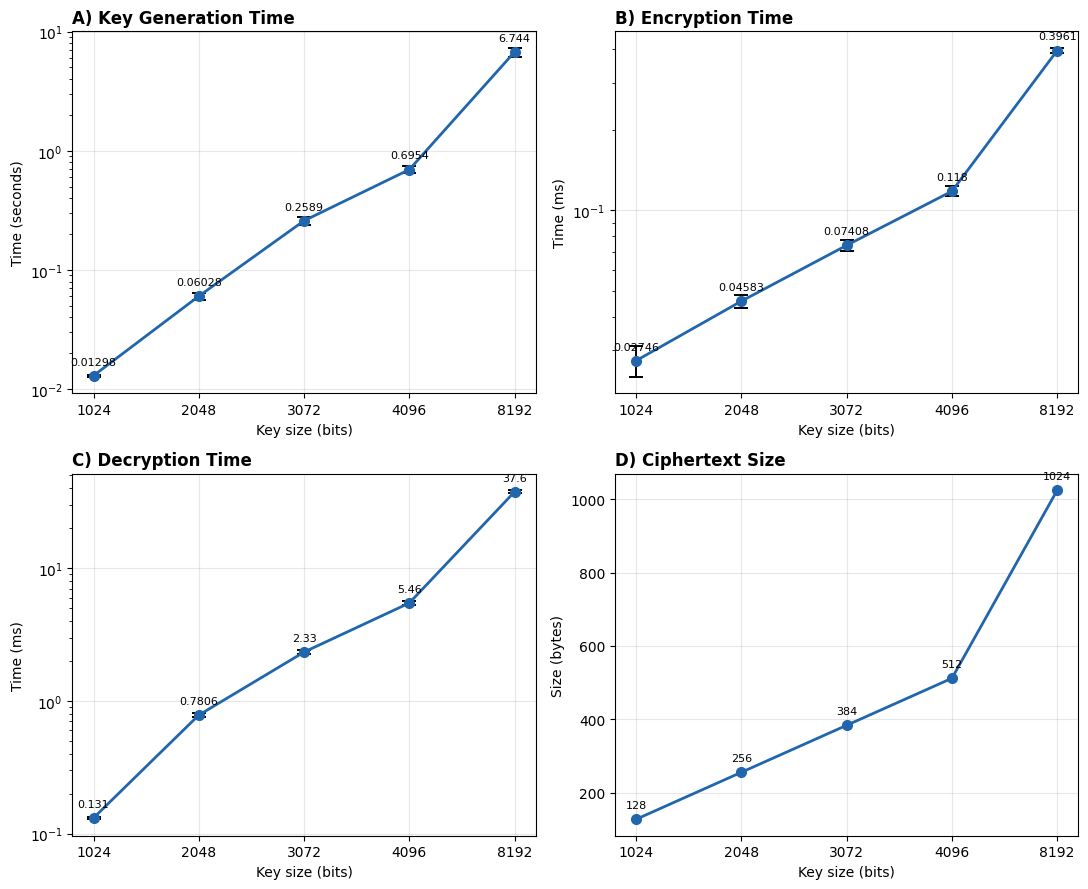

Figure saved to figures/Figure 2 - RSA Performance Scaling.png
Table and figure numbers (including error bars) verified consistent.


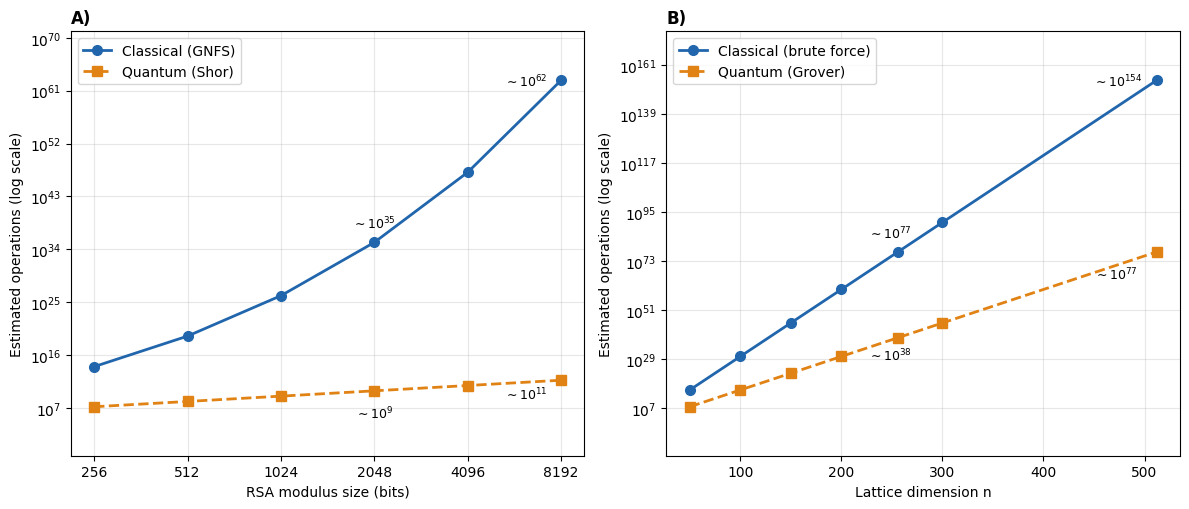

Saved to figures/Figure 1 - Quantum Complexity Comparison.png

At 2048-bit RSA: GNFS ~10^35 ops vs Shor ~10^9 ops
At n=256 LWE:  classical ~10^77 ops vs Grover ~10^38 ops (still astronomically hard)
Note for text: Grover at n=512 (~10^77) equals classical at n=256 (~10^77) -- the 'double the dimension' defense, visible directly on the graph.


In [10]:
# One cell: full pipeline
from run_rsa_benchmark import main
from generate_rsa_table_and_figure import generate_table_and_figure
from plot_complexity_figure import plot_complexity_figure

df = main(reuse_csv=True)                 # benchmark (or reuse) + verify
generate_table_and_figure("rsa_benchmark_results.csv")   # Table 1 + Figure 2
plot_complexity_figure("figures/Figure 1 - Quantum Complexity Comparison.png")                                  # Figure 1

In [11]:
import os, zipfile
from google.colab import files

RSA_ARTIFACTS = [
    # modules (the repo's Python files)
    "rsa_implementation.py",
    "run_config.py",
    "benchmark_rsa.py",
    "verify_rsa_results.py",
    "run_rsa_benchmark.py",
    "generate_rsa_table_and_figure.py",
    "plot_complexity_figure.py",
    # data
    "rsa_benchmark_results.csv",
    "Table 1 - RSA Performance Summary.csv",
    # figures
    "figures/Figure 1 - Quantum Complexity Comparison.png",
    "figures/Figure 2 - RSA Performance Scaling.png",
]

# Deliberately NOT included:
#   rsa_benchmark_checkpoint.csv     -- working artifact; committing it would invite
#                                       someone to resume a run across sessions
#   encryption_time_line_chart.png   -- diagnostic only, not a manuscript figure

missing = [f for f in RSA_ARTIFACTS if not os.path.exists(f)]
present = [f for f in RSA_ARTIFACTS if os.path.exists(f)]
if missing:
    print("MISSING (check these before pushing):")
    for f in missing:
        print("   ", f)
    print()

with zipfile.ZipFile("qsafe_rsa_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for f in present:
        z.write(f)
print(f"Zipped {len(present)} files -> qsafe_rsa_artifacts.zip")
files.download("qsafe_rsa_artifacts.zip")

Zipped 11 files -> qsafe_rsa_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>